# Earth Loading Love Numbers: TidalPy vs Published Models

The 1D radial solver computes a body's Love numbers from its interior structure. This benchmark compares it against two Earth models from the literature:

- **Guo et al. (2004)**: a PREM-like three-layer Earth (solid inner core, liquid outer core, solid mantle),
- **Farrell (1972)**: the Gutenberg Earth model of Alterman et al. (1961, Table 4), which Farrell calls Gutenberg-Bullen A: a liquid core under a solid mantle.

The comparison is of the surface loading Love numbers `h'` and `k'` against harmonic degree, computed by `RadialSolver` from each model's density and seismic-velocity profile, against the values those papers report.

The reference datasets `Guo+2004.npy` and `Farrell1972.npy` sit next to this notebook. Each is a radial profile with columns `[radius (km), density (g/cc), Vs (km/s), Vp (km/s)]`, center to surface. A radius listed twice marks a discontinuity: the first row belongs to the material below it and the second to the material above. Each one becomes a layer boundary of the solve (`split_at_discontinuities`), so the integration restarts at every jump rather than stepping across it, which is faster and more accurate (for the Farrell model, whose crust and mantle are homogeneous shells, it lowers the integration error in $h'$ from about $10^{-4}$ to below $10^{-9}$). The elastic moduli come from the seismic velocities: `mu = Vs^2 rho`, `K = Vp^2 rho - (4/3) mu`.


In [1]:
%matplotlib inline
import logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

logging.disable(logging.WARNING)   # the solver notes high step counts for the stiff high-degree solves

from TidalPy.RadialSolver import build_rs_input_from_data, radial_solver
from TidalPy.Rheology import Elastic   # purely elastic response for a Love-number comparison

HERE = Path().resolve()
FORCING = 2.0 * np.pi / 86400.0          # one-day forcing (the value is immaterial for elastic Love numbers)

MIN_ROWS_PER_LAYER = 6                   # the solver needs at least 5 slices in each layer


def split_at_discontinuities(data, upper_radii, layer_types, is_static):
    """Declare a layer boundary at every radius the profile lists twice, so the solver restarts its integration at each
    jump instead of stepping across it. Each sub-layer takes the state of the declared layer it lies in. Midpoints
    along each segment give every sub-layer enough slices without changing the piecewise-linear profile."""
    radius_km = data[:, 0]
    repeated = radius_km[1:][np.diff(radius_km) == 0.0] * 1e3
    tops = sorted([float(radius) for radius in repeated
                   if radius < upper_radii[-1] and not np.any(np.isclose(radius, upper_radii, rtol=0.0, atol=1.0))]
                  + list(upper_radii))
    owner = [int(np.searchsorted(np.asarray(upper_radii), top - 1.0)) for top in tops]
    blocks = []
    edges = np.concatenate(([0], np.flatnonzero(np.diff(radius_km) == 0.0) + 1, [len(data)]))
    for start, stop in zip(edges[:-1], edges[1:]):
        block = data[start:stop]
        while len(block) < MIN_ROWS_PER_LAYER:
            refined = np.empty((2 * len(block) - 1, block.shape[1]))
            refined[0::2], refined[1::2] = block, 0.5 * (block[:-1] + block[1:])
            block = refined
        blocks.append(block)
    return (np.concatenate(blocks), tuple(tops), tuple(layer_types[index] for index in owner),
            tuple(is_static[index] for index in owner))


def load_model(filename, upper_radii, layer_types, is_static):
    "Return a solver for one Earth model: solve(degree, incompressible) -> (h', k', success)."
    data, upper_radii, layer_types, is_static = split_at_discontinuities(
        np.load(HERE / filename), upper_radii, layer_types, is_static)
    radius = data[:, 0] * 1e3
    density = data[:, 1] * 1e3
    shear = (data[:, 2] * 1e3)**2 * density
    bulk = (data[:, 3] * 1e3)**2 * density - (4.0 / 3.0) * shear
    dummy_visc = np.full_like(radius, 1e30)   # unused for an elastic rheology
    n_layers = len(layer_types)

    def solve(degree, incompressible):
        rs_input = build_rs_input_from_data(
            FORCING, radius, density, bulk, shear, dummy_visc, dummy_visc,
            upper_radii, layer_types, is_static, tuple(incompressible for _ in range(n_layers)),
            Elastic(), Elastic(),   # one rheology model applies to every layer
            perform_checks=False, warnings=False)
        # Loading alone: degree 1 has load Love numbers, but a degree-1 tide is a translation of the body.
        sol = radial_solver(*rs_input, degree_l=degree, solve_for=("loading",),
                            use_kamata=incompressible, nondimensionalize=True,
                            integration_method="RK45", starting_radius=0.0,
                            integration_rtol=1e-8, integration_atol=1e-12)
        h_load = complex(sol.h).real
        k_load = complex(sol.k).real
        return h_load, k_load, sol.success
    return solve

guo = load_model(
    "Guo+2004.npy",
    (1.2225e6, 3.4810e6, 6.3710e6),  # Upper radius of layers
    ("solid", "liquid", "solid"),
    (False, True, False)  # If layer is static or dynamic
)
farrell = load_model(
    "Farrell1972.npy",
    (3.473e6, 6.371e6),
    ("liquid", "solid"),
    (True, False)
)
print("models loaded")

models loaded


## Guo et al. (2004)

TidalPy's loading Love numbers, computed with both compressible and incompressible assumptions, against the reference values. The reference `k'` is reported as `n * k'`, so it is divided by degree to compare with the solver's `k'`. The compressible curve tracks the reference across every degree. Making the Earth incompressible visibly changes the response.

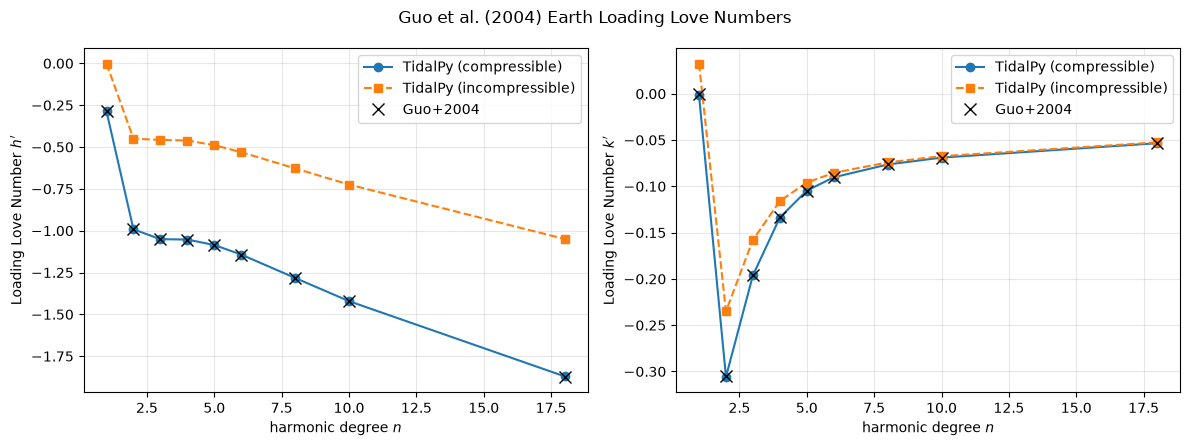

[TidalPy] [warning] Large number of steps taken found in radial solver solution (max = 218093).
[TidalPy] [warning] Large number of steps taken found in radial solver solution (max = 218093).


  n  h_TidalPy    h_Guo  k_TidalPy    k_Guo
  1    -0.2872  -0.2856    -0.0016  -0.0000
  2    -0.9919  -0.9909    -0.3058  -0.3051
  3    -1.0507  -1.0501    -0.1962  -0.1959
  4    -1.0529  -1.0528    -0.1337  -0.1335
  5    -1.0855  -1.0857    -0.1047  -0.1046
  6    -1.1428  -1.1433    -0.0903  -0.0902
  8    -1.2823  -1.2833    -0.0764  -0.0764
 10    -1.4211  -1.4226    -0.0690  -0.0689
 18    -1.8704  -1.8733    -0.0535  -0.0534


In [2]:
degrees = np.array([1, 2, 3, 4, 5, 6, 8, 10, 18])
guo_h_ref = -np.array([0.2856, 0.9909, 1.0501, 1.0528, 1.0857, 1.1433, 1.2833, 1.4226, 1.8733])
guo_kn_ref = -np.array([0, 0.6103, 0.5876, 0.5341, 0.5228, 0.5411, 0.61107, 0.6893, 0.961])
guo_k_ref = guo_kn_ref / degrees      # the paper plots n * k'

h_comp = np.array([guo(d, False)[0] for d in degrees])
k_comp = np.array([guo(d, False)[1] for d in degrees])
h_inco = np.array([guo(d, True)[0] for d in degrees])
k_inco = np.array([guo(d, True)[1] for d in degrees])

fig, (axh, axk) = plt.subplots(1, 2, figsize=(12, 4.5))
axh.plot(degrees, h_comp, "o-", label="TidalPy (compressible)")
axh.plot(degrees, h_inco, "s--", label="TidalPy (incompressible)")
axh.plot(degrees, guo_h_ref, "kx", ms=9, label="Guo+2004")
axh.set_ylabel("Loading Love Number $h'$")
axk.plot(degrees, k_comp, "o-", label="TidalPy (compressible)")
axk.plot(degrees, k_inco, "s--", label="TidalPy (incompressible)")
axk.plot(degrees, guo_k_ref, "kx", ms=9, label="Guo+2004")
axk.set_ylabel("Loading Love Number $k'$")
for ax in (axh, axk):
    ax.set_xlabel("harmonic degree $n$"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Guo et al. (2004) Earth Loading Love Numbers")
fig.tight_layout(); plt.show()

print(f"{'n':>3} {'h_TidalPy':>10} {'h_Guo':>8} {'k_TidalPy':>10} {'k_Guo':>8}")
for i, d in enumerate(degrees):
    print(f"{d:3d} {h_comp[i]:10.4f} {guo_h_ref[i]:8.4f} {k_comp[i]:10.4f} {guo_k_ref[i]:8.4f}")


## Farrell (1972)

Farrell (1972) tabulates the loading Love numbers of the Gutenberg-Bullen A Earth model, which he took from Alterman et al. (1961). `Farrell1972.npy` is built from Alterman et al. (1961) Table 4 (pp. 225-226), digitized in `Alterman1961_Gutenberg.csv`. The table prints each crust and mantle value between two depth labels, so each of these rows is a homogeneous shell: the file lists every shell boundary radius twice, once for the shell below and once for the shell above. The table prints each core value on its depth label, so the core rows are point values and are interpolated linearly. Longman (1963, p. 490) reads the table the same way.

The reference values come from Farrell's Table A2 (p. 791), digitized in `Farrell1972_LoveNumbers.csv` with the table's columns $n$, $-h'_n$, $n l'_n$, and $-n k'_n$. Farrell's degree-1 values are in the frame of the center of mass of the undeformed Earth, where $k'_1 = 0$ (his section 3c). A translation of the origin changes $h'_1$, $l'_1$, and $k'_1$ by the same amount (Blewitt, 2003), so TidalPy's degree-1 $h'$ is shifted by $-k'_1$ into that frame before the comparison.

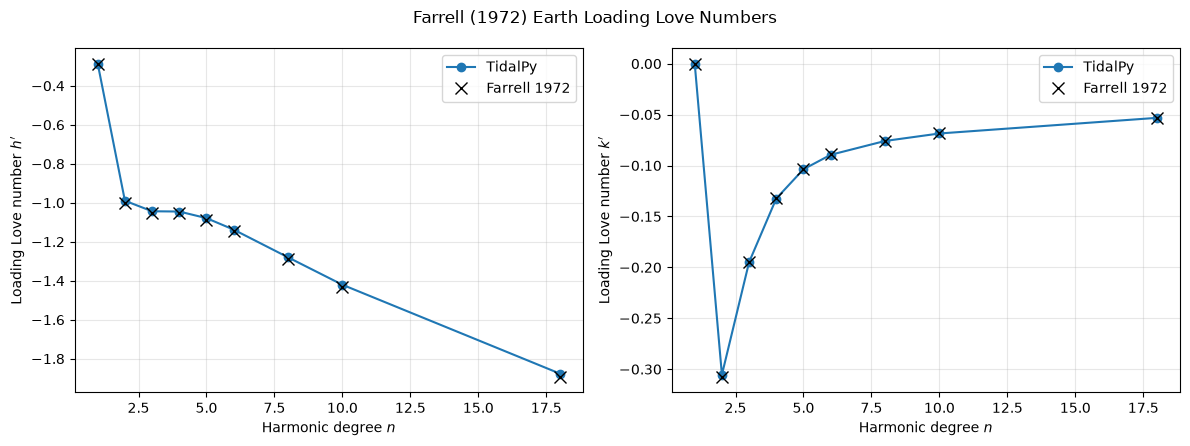

  n  h_TidalPy  h_Farrell  diff (%)  k_TidalPy  k_Farrell  diff (%)
  1    -0.2864    -0.2900     -1.24     0.0000    -0.0000         -
  2    -0.9897    -1.0010     -1.13    -0.3054    -0.3075     -0.67
  3    -1.0436    -1.0520     -0.80    -0.1949    -0.1950     -0.05
  4    -1.0450    -1.0530     -0.76    -0.1324    -0.1320      0.32
  5    -1.0789    -1.0880     -0.84    -0.1037    -0.1032      0.47
  6    -1.1377    -1.1470     -0.81    -0.0895    -0.0892      0.37
  8    -1.2799    -1.2910     -0.86    -0.0759    -0.0755      0.54
 10    -1.4206    -1.4330     -0.87    -0.0686    -0.0682      0.52
 18    -1.8764    -1.8930     -0.88    -0.0532    -0.0529      0.60


In [3]:
# Farrell (1972) Table A2: columns n, -h'_n, n l'_n, -n k'_n
far_table = np.loadtxt(HERE / "Farrell1972_LoveNumbers.csv", delimiter=",", comments="#")
far_degrees = np.array([1, 2, 3, 4, 5, 6, 8, 10, 18])
far_rows = np.searchsorted(far_table[:, 0], far_degrees)
far_h_ref = -far_table[far_rows, 1]
far_k_ref = -far_table[far_rows, 3] / far_degrees   # the table lists -n k'

far_results = [farrell(d, False) for d in far_degrees]
assert all(result[2] for result in far_results), "a Farrell (1972) solve failed"
fh = np.array([result[0] for result in far_results])
fk = np.array([result[1] for result in far_results])
# Degree 1: move TidalPy's values into Farrell's frame (k'_1 = 0); a translation shifts h'_1 and k'_1 equally
fh[0] -= fk[0]
fk[0] = 0.0

fig, (axh, axk) = plt.subplots(1, 2, figsize=(12, 4.5))
axh.plot(far_degrees, fh, "o-", label="TidalPy")
axh.plot(far_degrees, far_h_ref, "kx", ms=9, label="Farrell 1972")
axh.set_ylabel("Loading Love number $h'$")
axk.plot(far_degrees, fk, "o-", label="TidalPy")
axk.plot(far_degrees, far_k_ref, "kx", ms=9, label="Farrell 1972")
axk.set_ylabel("Loading Love number $k'$")
for ax in (axh, axk):
    ax.set_xlabel("Harmonic degree $n$"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Farrell (1972) Earth Loading Love Numbers")
fig.tight_layout(); plt.show()

print(f"{'n':>3} {'h_TidalPy':>10} {'h_Farrell':>10} {'diff (%)':>9} {'k_TidalPy':>10} {'k_Farrell':>10} {'diff (%)':>9}")
for i, d in enumerate(far_degrees):
    h_diff = 100.0 * (fh[i] / far_h_ref[i] - 1.0)
    k_diff = f"{100.0 * (fk[i] / far_k_ref[i] - 1.0):9.2f}" if far_k_ref[i] != 0.0 else f"{'-':>9}"
    print(f"{d:3d} {fh[i]:10.4f} {far_h_ref[i]:10.4f} {h_diff:9.2f} {fk[i]:10.4f} {far_k_ref[i]:10.4f} {k_diff}")


TidalPy's $h'$ is 0.8 to 1.2% smaller than Farrell's at every degree from 1 to 18, and $k'$ is within 1%. Farrell computed his Love numbers to an accuracy of 0.01% (p. 781), so the difference comes from the Earth model rather than from either integration. The likely source is the gravity of the published model:

- Alterman et al. (1961, Table 4) tabulate a gravity of 10.37 m s$^{-2}$ at the core-mantle boundary and 9.82 m s$^{-2}$ at the surface.
- Their tabulated densities give about 10.1 m s$^{-2}$ at the core-mantle boundary and 9.77 m s$^{-2}$ at the surface. The difference is in the core: the tabulated core gravity implies a core mass 2.8% larger than the tabulated core densities do (Longman, 1963, Table 1).
- `Farrell1972.npy` keeps the tabulated densities, and TidalPy computes gravity from them.
- Raising the core density until the core-mantle boundary gravity is 10.37 m s$^{-2}$ moves TidalPy's $h'$ to 0.8 to 1.0% above Farrell's at degrees 3 to 18, so the model's own inconsistency spans the difference.

Farrell does not state which gravity profile he used. Independent calculations on this model differ by a similar amount: Longman's (1963, Table 2) $-h'_n$ is 0.4 to 0.7% larger than Farrell's at every degree from 2 to 18.

## References

- Alterman, Z., Jarosch, H., & Pekeris, C. L. (1961). Propagation of Rayleigh waves in the Earth. _Geophysical Journal_, 4, 219-241.
- Blewitt, G. (2003). Self-consistency in reference frames, geocenter definition, and surface loading of the solid Earth. _Journal of Geophysical Research_, 108(B2), 2103.
- Farrell, W. E. (1972). Deformation of the Earth by surface loads. _Reviews of Geophysics and Space Physics_, 10(3), 761-797.
- Guo, J. Y., Li, Y. B., Huang, Y., Deng, H. T., Xu, S. Q., & Ning, J. S. (2004). Green's function of the deformation of the Earth as a result of atmospheric loading. _Geophysical Journal International_, 159, 53-68.
- Longman, I. M. (1963). A Green's function for determining the deformation of the Earth under surface mass loads, 2. Computations and numerical results. _Journal of Geophysical Research_, 68(2), 485-496.